In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import psutil
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# 1. Carregar os dados
CSV_PATH = "../data/results.csv"
df = pd.read_csv(CSV_PATH)

# 2. Contexto de Hardware
n_cores = psutil.cpu_count()
print(f"Hardware detectado: {n_cores} núcleos lógicos.")
print(f"Nota: Valores de CPU até {n_cores*100}% são esperados devido ao paralelismo do NumPy/OS.")

# 3. Criação de métricas derivadas para análise profunda
# Custo Total (Trabalho): Quantidade de processamento real (Tempo * Intensidade)
df['cpu_workload'] = (df['cpu_usage_percent'] / 100) * df['wall_time_ms']

# Normalização para escala 0-100% da máquina total
df['cpu_percent_total_machine'] = df['cpu_usage_percent'] / n_cores

sns.set_theme(style="whitegrid")

Hardware detectado: 12 núcleos lógicos.
Nota: Valores de CPU até 1200% são esperados devido ao paralelismo do NumPy/OS.


C:\Users\maria\AppData\Local\Temp\ipykernel_52736\689985687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\689985687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\689985687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\689985687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

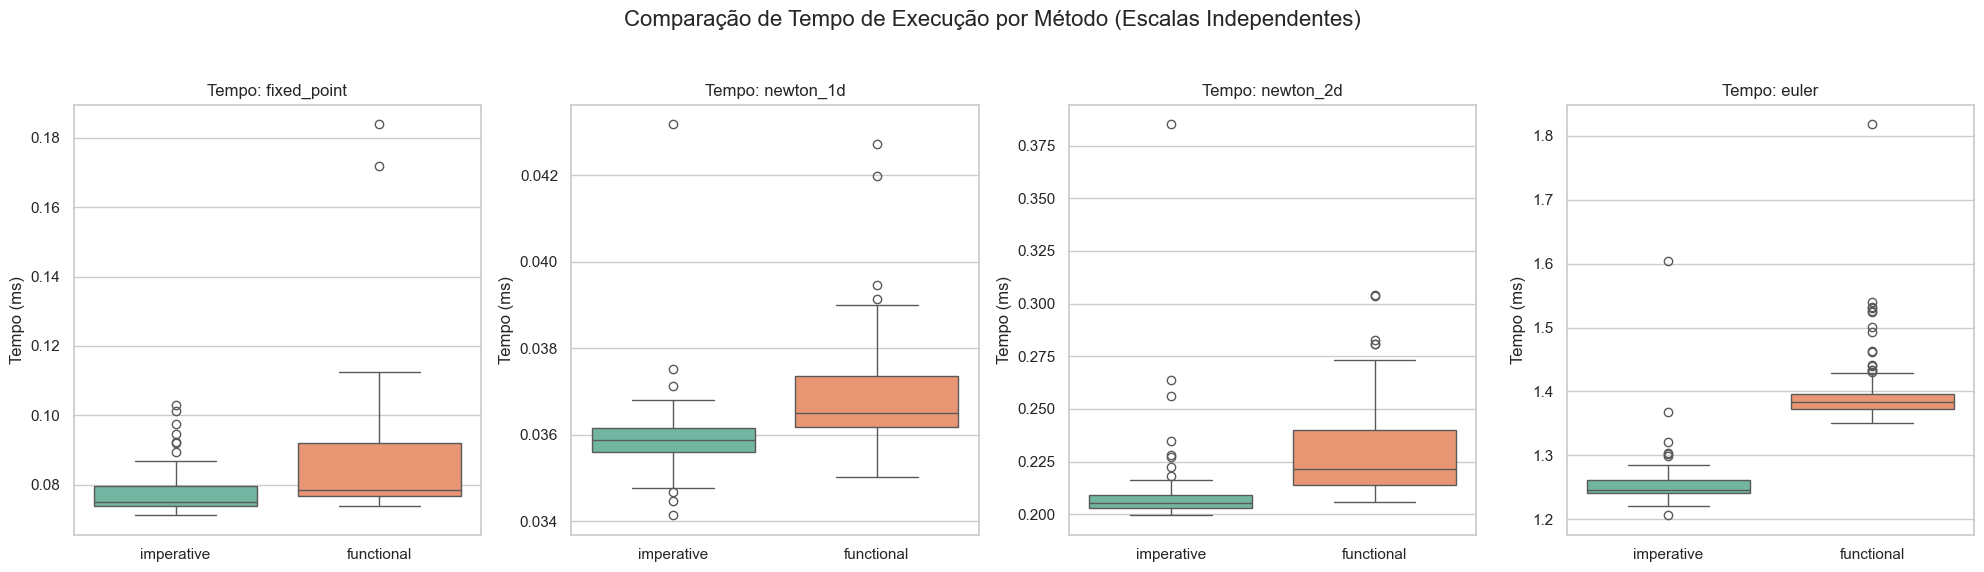

In [3]:
# Criando uma grade de subplots (1 linha, 4 colunas para os 4 métodos)
metodos = df['method'].unique()
fig, axes = plt.subplots(1, len(metodos), figsize=(20, 6), sharey=False)

for i, metodo in enumerate(metodos):
    sns.boxplot(
        data=df[df['method'] == metodo], 
        x='paradigm', 
        y='wall_time_ms', 
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f'Tempo: {metodo}')
    axes[i].set_ylabel('Tempo (ms)')
    axes[i].set_xlabel('')

plt.suptitle('Comparação de Tempo de Execução por Método (Escalas Independentes)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2838122822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2838122822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2838122822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2838122822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

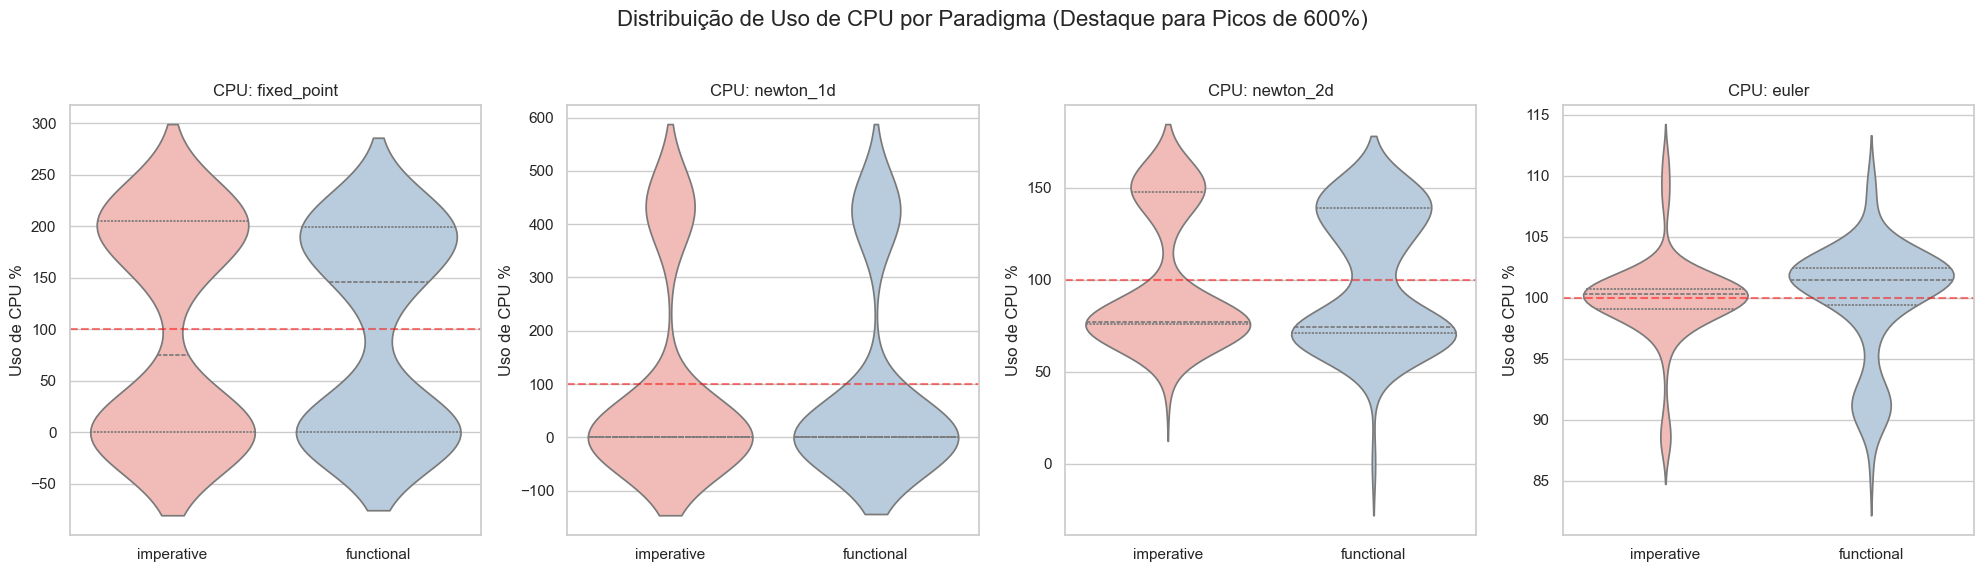

In [ ]:
fig, axes = plt.subplots(1, len(metodos), figsize=(20, 6), sharey=False)

for i, metodo in enumerate(metodos):
    sns.violinplot(
        data=df[df['method'] == metodo], 
        x='paradigm', 
        y='cpu_usage_percent', 
        ax=axes[i], 
        palette='Pastel1',
        inner="quart"
    )
    
    axes[i].axhline(100, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'CPU: {metodo}')
    axes[i].set_ylabel('Uso de CPU %')
    axes[i].set_xlabel('')

plt.suptitle('Distribuição de Uso de CPU por Paradigma (Destaque para Picos de 600%)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2840693222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2840693222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2840693222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maria\AppData\Local\Temp\ipykernel_52736\2840693222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

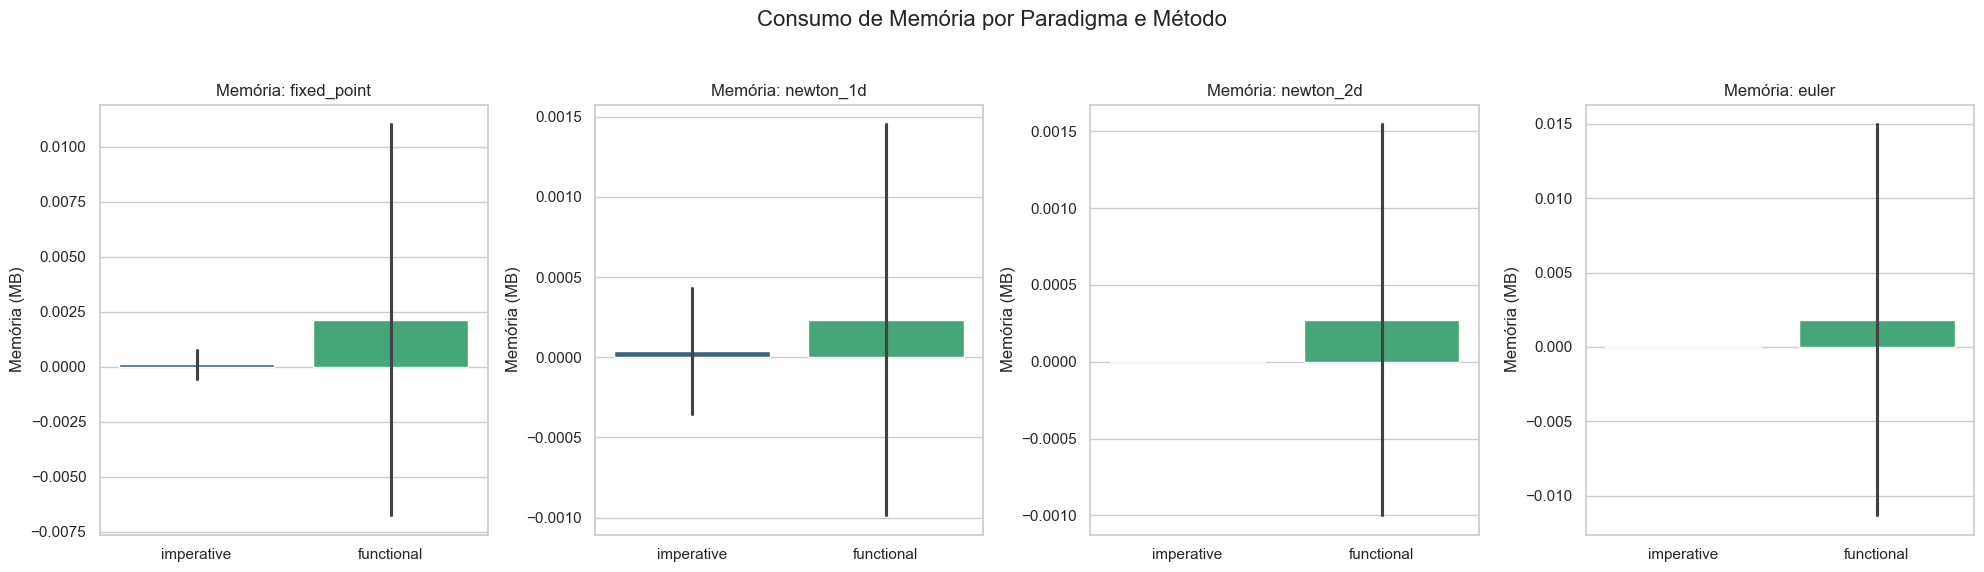

In [5]:
fig, axes = plt.subplots(1, len(metodos), figsize=(20, 6), sharey=False)

for i, metodo in enumerate(metodos):
    sns.barplot(
        data=df[df['method'] == metodo], 
        x='paradigm', 
        y='memory_used_mb', 
        ax=axes[i], 
        palette='viridis',
        errorbar='sd'
    )
    axes[i].set_title(f'Memória: {metodo}')
    axes[i].set_ylabel('Memória (MB)')
    axes[i].set_xlabel('')

plt.suptitle('Consumo de Memória por Paradigma e Método', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [11]:
fig1 = px.box(df, x="paradigm", y="wall_time_ms", color="method",
             points="all", # Mostra todos os 100 pontos ao lado do box
             log_y=True,   # Escala logarítmica para ver todos os métodos
             title="Tempo de Execução (Interativo)",
             labels={"wall_time_ms": "Tempo (ms)", "method": "Método"},
             color_discrete_sequence=px.colors.qualitative.Set2)

fig1.update_layout(height=600)
fig1.show()

In [15]:
fig2 = px.violin(df, x="paradigm", y="cpu_usage_percent", color="method",
                box=True, # Adiciona um boxplot pequeno dentro do violino
                points="suspectedoutliers",
                title="Distribuição de Intensidade de CPU",
                labels={"cpu_usage_percent": "Uso de CPU %"},
                color_discrete_sequence=px.colors.qualitative.Pastel)

# Adicionando a linha de referência de 100% (1 núcleo)
fig2.add_hline(y=100, line_dash="dash", line_color="#C0C0C0", annotation_text="Limite 1 Núcleo")

fig2.update_layout(height=600)
fig2.show()

In [17]:
# Agrupando para calcular média e erro
df_mem = df.groupby(['method', 'paradigm'])['memory_used_mb'].agg(['mean', 'std']).reset_index()

fig3 = px.line(df_mem, x="method", y="mean", color="paradigm", markers=True,
              error_y="std", # Barras de erro baseadas no desvio padrão
              title="Média de Memória com Desvio Padrão",
              labels={"mean": "Memória Média (MB)"})

fig3.update_traces(marker=dict(size=10))
fig3.update_layout(height=600)
fig3.show()

In [19]:
fig4 = px.bar(df, x="method", y="cpu_workload", color="paradigm",
             barmode="group",
             title="Esforço Total de Processamento (Workload)",
             labels={"cpu_workload": "Trabalho (ms * % CPU)"},
             color_discrete_sequence=px.colors.sequential.Viridis)

fig4.update_layout(height=600)
fig4.show()

In [21]:

fig_scatter = px.scatter(df, 
                         x="wall_time_ms", 
                         y="cpu_usage_percent", 
                         color="method",      # Agrupamento principal por MÉTODO
                         symbol="paradigm",   # Diferenciação por paradigma
                         hover_data=['run_id'],
                         title="Trade-off: Tempo vs Intensidade de CPU (Por Método)",
                         labels={"wall_time_ms": "Tempo (ms)", "cpu_usage_percent": "CPU %"})

# Aplicamos escala log no X para não esmagar o Newton 1D
fig_scatter.update_xaxes(type="log")
fig_scatter.show()

In [24]:
fig_sun = px.sunburst(df, 
                      path=['method'], # Hierarquia: Método primeiro
                      values='cpu_workload',        # O tamanho da fatia é o esforço total
                      color='cpu_workload',
                      color_continuous_scale='RdBu',
                      title="Distribuição Hierárquica do Esforço de Processamento")
fig_sun.show()

In [28]:
# Agrupando os dados para ter uma média por combinação
df_heatmap = df.groupby(['method', 'paradigm'])['cpu_workload'].mean().unstack()

fig_heat = px.imshow(df_heatmap,
                labels=dict(x="Paradigma", y="Método", color="Custo de Processamento"),
                x=df_heatmap.columns,
                y=df_heatmap.index,
                text_auto=True, # Mostra os valores dentro dos quadrados
                aspect="auto",
                color_continuous_scale='YlOrRd',
                title="Mapa de Calor: Intensidade de Esforço (Workload) por Método")

fig_heat.show()

In [38]:
# Gráfico de Violino para CPU (Onde os 600% aparecem como densidade)
fig_violin = px.violin(df, 
                       x="paradigm", 
                       y="cpu_usage_percent", 
                       color="method", 
                       box=True,      # Adiciona o boxplot interno
                       points="all",  # Mostra todos os pontos para transparência total
                       hover_data=['run_id'],
                       title="Violin Plot: Distribuição de CPU Agrupada por Método",
                       labels={"cpu_usage_percent": "CPU (%)"},
                       color_discrete_sequence=px.colors.qualitative.Vivid)

fig_violin.add_hline(y=100, line_dash="dash", line_color="#9C9C9C", annotation_text="Teto 1 Núcleo")
fig_violin.show()